# REINFORCE

---

In this notebook, we will train REINFORCE with OpenAI Gym's Cartpole environment.

### 1. Import the Necessary Packages

In [1]:
import gymnasium as gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

import torch
torch.manual_seed(0) # set random seed
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

### 2. Define the Architecture of the Policy

In [2]:
env = gym.make('CartPole-v1', render_mode='rgb_array')
print('observation space:', env.observation_space)
print('action space:', env.action_space)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define the Policy Network
class Policy(nn.Module):
    def __init__(self, s_size=4, h_size=16, a_size=2):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(s_size, h_size)
        self.fc2 = nn.Linear(h_size, a_size) # Network has only one hidden layer with 16 units, and an output layer with 2 units (one for each action)

    # Forward step of the network, which returns the 2 action probabilities
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=1)
    
    # Getting the action (from the agent) given the state, and the log probability of that action. 
    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


### 3. Train the Agent with REINFORCE

### Compute returns-to-go

For each episode $i$, compute $G_t^{(i)}$ backward:

1. Set $G \leftarrow 0$
2. For $t = T_i - 1, T_i - 2, \ldots, 0$:
   $$
   \begin{align*}
   G &\leftarrow r_t^{(i)} + \gamma G \\
   G_t^{(i)} &\leftarrow G
   \end{align*}
   $$

### Compute policy gradient estimate

Compute:
$$
\hat{g} = \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T_i - 1} \nabla_\theta \log \pi_\theta \left(a_t^{(i)} \mid s_t^{(i)}\right) G_t^{(i)}
$$

### Update policy

$$
\theta \leftarrow \theta + \alpha \hat{g}
$$


In [4]:
policy = Policy().to(device) # initialising the agent network

# defining the optimizer for the agent network, you can experiment with different learning rates and optimizers
optimizer = optim.Adam(policy.parameters(), lr=1e-2) 

def reinforce(n_episodes=5000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100) # buffer to store the last 100 scores
    scores = []

    # loop through all episodes
    for i_episode in range(1, n_episodes+1):
        saved_log_probs = []
        rewards = []
        state, _ = env.reset(seed=0) 

        # timestep loop for each episode
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ , _ = env.step(action)
            rewards.append(reward)
            if done:
                break 
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))
        
        # pythonic way to calculate the discounted return R
        # discounts = [gamma**i for i in range(len(rewards)+1)] 
        # R = sum([a*b for a,b in zip(discounts, rewards)])

        # discounted sum of returns R 
        """R = 0
        for i in range(len(rewards)):
            R += gamma**i * rewards[i] """

        # Compute return-to-go
        # Initialize
        G = 0
        G_list = [0]*len(rewards)

        # Calculation loop
        for i in range(len(rewards)-1,-1,-1):   # Start from last index and go to 0 (-1 is excluded)
            G = rewards[i]+gamma*G  # Get new G
            G_list[i] = G           # Save to list

        # Convert to tensors for efficiency
        #saved_log_probs_tensor = torch.tensor(saved_log_probs, dtype=torch.float32).to(device)
        #G_list_tensor = torch.tensor(G_list, dtype=torch.float32).to(device)

        # calculating the log loss for the episode
        #policy_loss = (-saved_log_probs_tensor*G_list_tensor).sum()
        policy_loss = []
        for i, log_prob in enumerate(saved_log_probs):
            policy_loss.append(-log_prob * G_list[i])
        policy_loss = torch.cat(policy_loss).sum()

        # perform backpropagation and update the policy network
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        if i_episode % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_deque)))
        if np.mean(scores_deque)>=195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_deque)))
            break
        
    return scores
    
scores = reinforce()

Episode 100	Average Score: 53.19
Episode 200	Average Score: 83.61
Environment solved in 166 episodes!	Average Score: 198.77


### 4. Plot the Scores

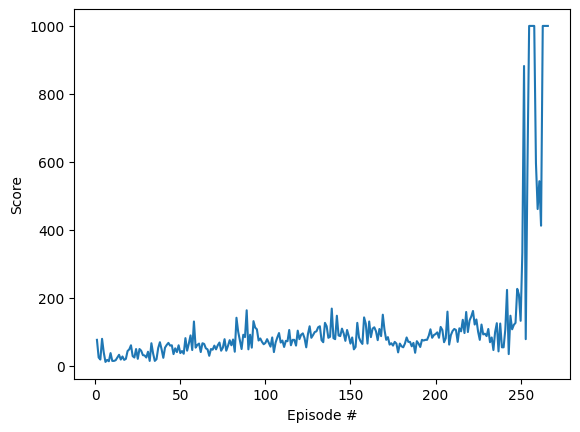

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(1, len(scores)+1), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

### 5. Watch a Smart Agent!

In [ ]:
env = gym.make('CartPole-v1', render_mode='human')

state, _ = env.reset(seed=0)
for t in range(1000):
    action, _ = policy.act(state)
    env.render()
    state, reward, done, _, _ = env.step(action)
    if done:
        break 

env.close()